In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("soil_pollution_diseases.csv")

/var/folders/bn/gcvl_htn4lz2y2d9h215n0vc0000gn/T/ipykernel_53032/3901235488.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




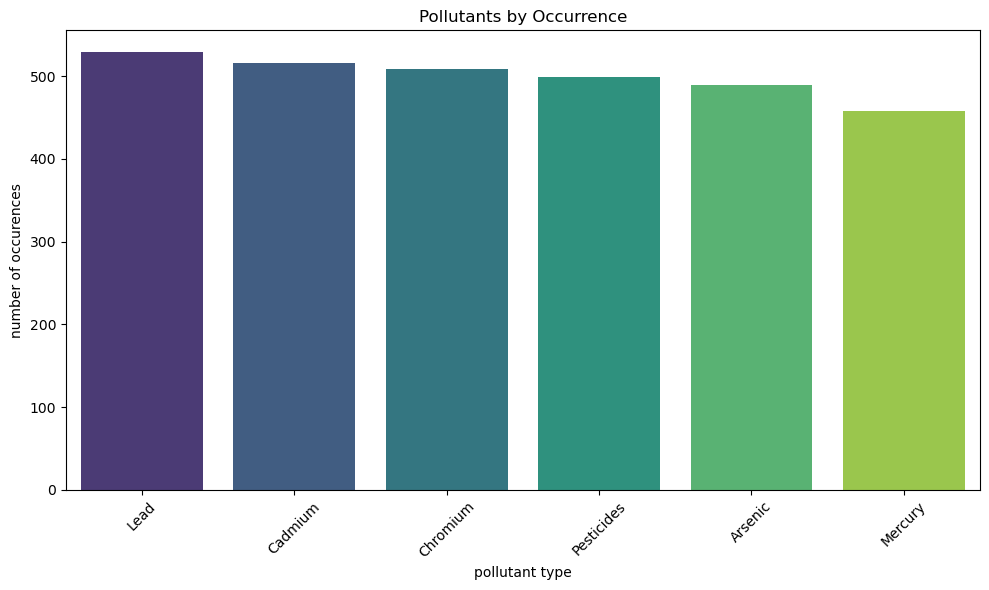

In [112]:
pollutant_counts = df['Pollutant_Type'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=pollutant_counts.index, y=pollutant_counts.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Pollutants by Occurrence')
plt.ylabel('number of occurences')
plt.xlabel('pollutant type')
plt.tight_layout()
plt.show()

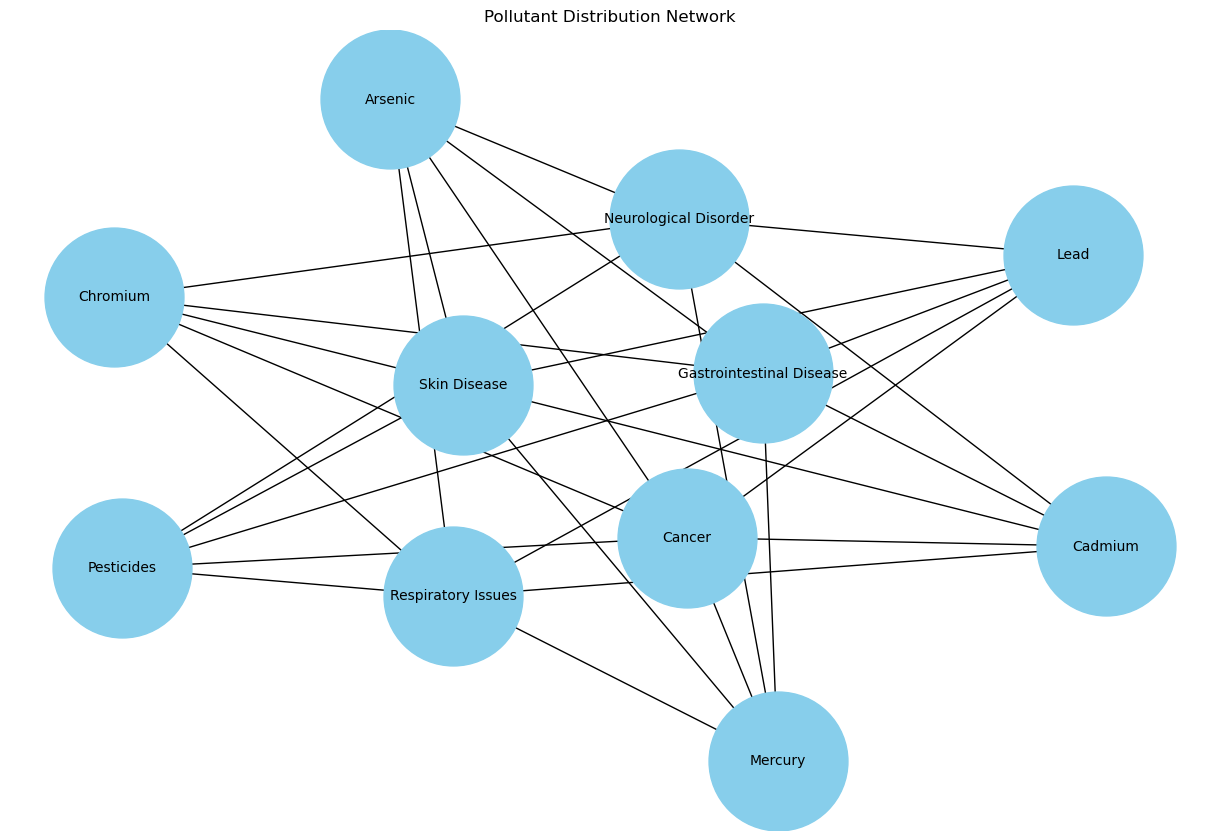

In [113]:
G = nx.from_pandas_edgelist(df, source='Pollutant_Type', target='Disease_Type')

plt.figure(figsize=(12, 8))
nx.draw(G, with_labels=True, node_color='skyblue', node_size=10000, font_size=10, edge_color='black')
plt.title("Pollutant Distribution Network")
plt.show()


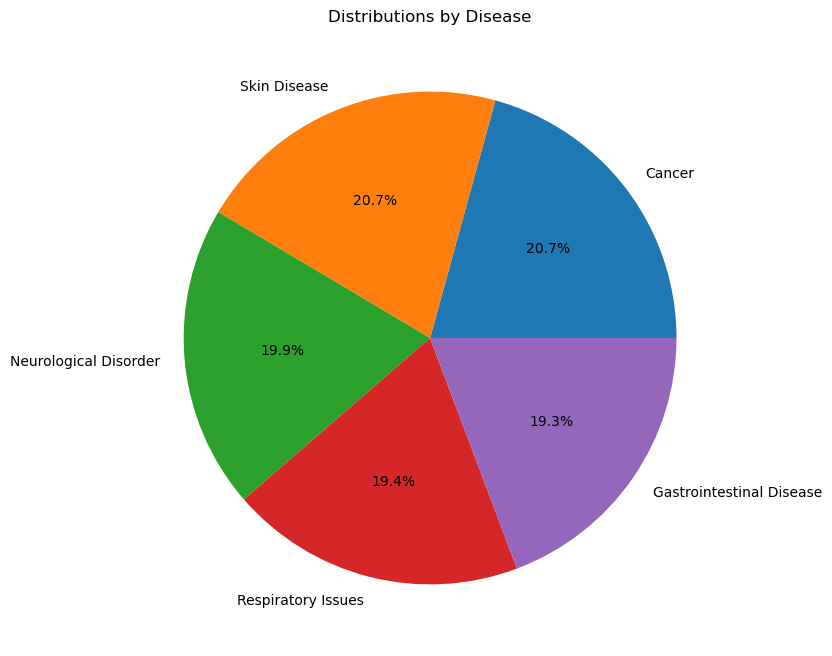

In [114]:
disease_counts = df['Disease_Type'].value_counts()

plt.figure(figsize=(8, 8))
disease_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Distributions by Disease')
plt.show()

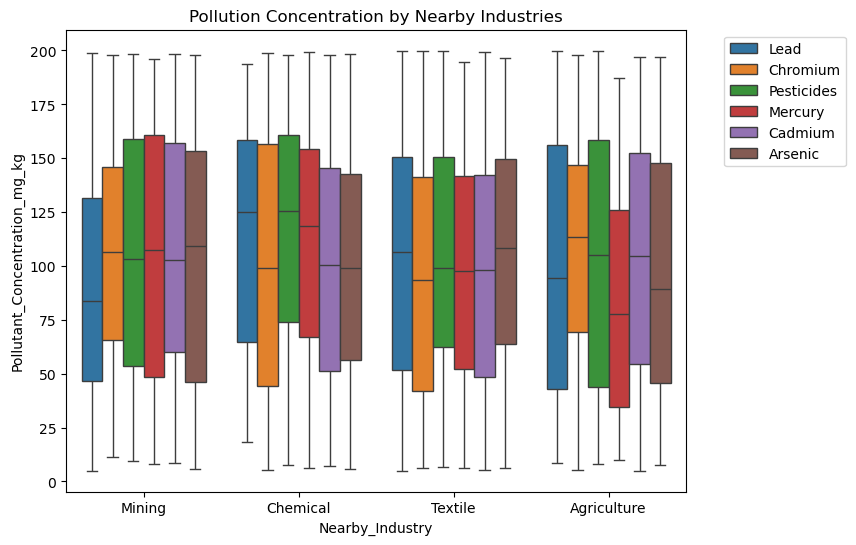

In [115]:
# Create box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Nearby_Industry', y='Pollutant_Concentration_mg_kg', hue='Pollutant_Type')
plt.title('Pollution Concentration by Nearby Industries')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

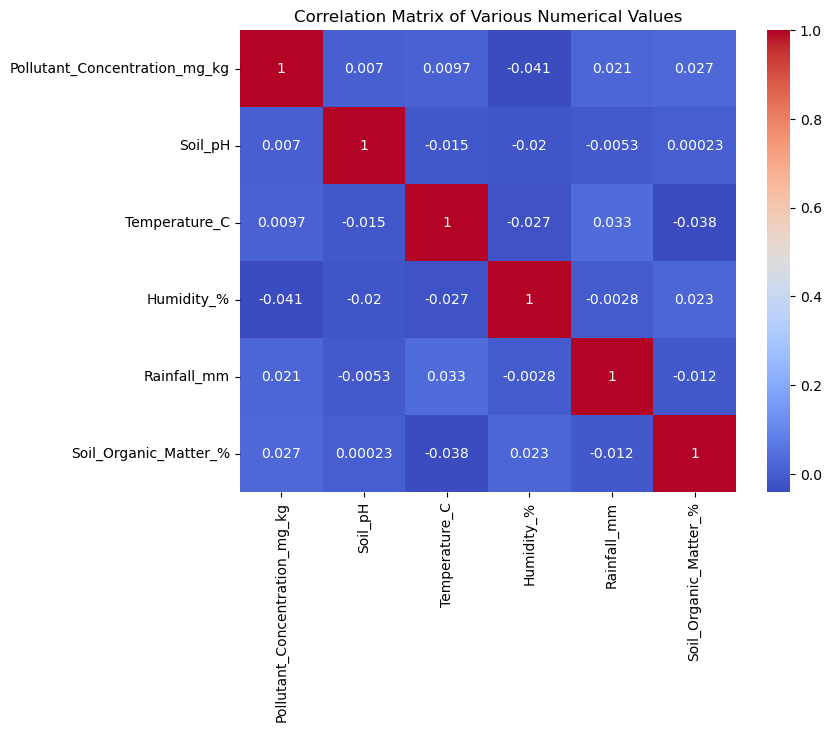

In [116]:
# Correlation Coefficient (Correlogram)
numeric_df = df.select_dtypes(include=['number'])
  
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix of Various Numerical Values')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [117]:
df.isnull().sum()

Case_ID                            0
Date_Reported                      0
Region                             0
Country                            0
Pollutant_Type                     0
Pollutant_Concentration_mg_kg      0
Soil_pH                            0
Temperature_C                      0
Humidity_%                         0
Rainfall_mm                        0
Crop_Type                          0
Farming_Practice                   0
Nearby_Industry                  582
Water_Source_Type                  0
Soil_Texture                       0
Soil_Organic_Matter_%              0
Disease_Type                       0
Disease_Severity                   0
Health_Symptoms                    0
Age_Group_Affected                 0
Gender_Most_Affected               0
Mitigation_Measure                 0
Case_Resolved                      0
Follow_Up_Required                 0
dtype: int64

In [ ]:
fig = px.box(df,
    x="Nearby_Industry",
    y="Pollutant_Concentration_mg_kg",
    color="Region",  # You can color by Region or another categorical column
    title="Pollutant Concentration vs Nearby Industry",
    labels={"Pollutant_Concentration_mg_kg": "Pollutant Concentration (mg/kg)"}
)
fig.show()


In [120]:
fig = px.treemap(
    df,
    path=["Region", "Farming_Practice"],  # Define the hierarchy
    values="Pollutant_Concentration_mg_kg",  # The variable to aggregate
    color="Pollutant_Concentration_mg_kg",
    color_continuous_scale="Viridis",
    title="Pollutant Concentration by Region and Farming Practice"
)
fig.show()


In [121]:
# Filter the DataFrame for Region = North America and Country = USA
na_usa_df = df[(df["Region"] == "North America") & (df["Country"] == "USA")].copy()

# Convert the Date_Reported column to datetime
na_usa_df["Date_Reported"] = pd.to_datetime(na_usa_df["Date_Reported"])

# Sort by date to ensure the line is ordered
na_usa_df = na_usa_df.sort_values("Date_Reported")

# Create the interactive line chart for USA (North America)
fig = px.line(
    na_usa_df,
    x="Date_Reported",
    y="Pollutant_Concentration_mg_kg",
    color="Pollutant_Type",  # You can switch this to 'Crop_Type' or another variable
    markers=True,
    title="Pollutant Concentration Over Time in the USA (North America)",
    labels={
        "Date_Reported": "Date",
        "Pollutant_Concentration_mg_kg": "Pollutant Concentration (mg/kg)"
    }
)

fig.update_layout(xaxis_title="Date", yaxis_title="Pollutant Concentration (mg/kg)")
fig.show()
